<a href="https://colab.research.google.com/github/Aliya02177/plant_disease_prediction-CNN/blob/main/plant_disease_prediction_CNN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
#set seeds for reproducibility
import random
random.seed(0)

import numpy as np
np.random.seed(0)

import tensorflow as tf
tf.random.set_seed(0)

importing dependencies

In [2]:
import os
import json
from zipfile import ZipFile
from PIL import Image

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras import layers, models

In [3]:
!pip install Kaggle

In [4]:
Kaggle_credentials=json.load(open("kaggle.json"))

In [5]:
#setup kaggle API key as environment variables
os.environ['KAGGLE_USERNAME']=Kaggle_credentials["username"]
os.environ['KAGGLE_KEY']=Kaggle_credentials["key"]


In [6]:
!kaggle datasets download -d abdallahalidev/plantvillage-dataset

Dataset URL: https://www.kaggle.com/datasets/abdallahalidev/plantvillage-dataset
License(s): CC-BY-NC-SA-4.0
100% 2.04G/2.04G [01:39<00:00, 21.9MB/s]



In [7]:
!ls

drive  kaggle.json  plantvillage-dataset.zip  sample_data


In [8]:
#unzip the downloaded dataset
with ZipFile("plantvillage-dataset.zip",'r') as zip_ref:
  zip_ref.extractall()

In [9]:
print(os.listdir("plantvillage dataset"))

print(len(os.listdir("plantvillage dataset/segmented")))
print(os.listdir("plantvillage dataset/segmented")[:5])

print(len(os.listdir("plantvillage dataset/color")))
print(os.listdir("plantvillage dataset/color")[:5])

print(len(os.listdir("plantvillage dataset/grayscale")))
print(os.listdir("plantvillage dataset/grayscale")[:5])



['color', 'segmented', 'grayscale']
38
['Potato___Early_blight', 'Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot', 'Grape___Black_rot', 'Potato___Late_blight', 'Tomato___Target_Spot']
38
['Potato___Early_blight', 'Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot', 'Grape___Black_rot', 'Potato___Late_blight', 'Tomato___Target_Spot']
38
['Potato___Early_blight', 'Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot', 'Grape___Black_rot', 'Potato___Late_blight', 'Tomato___Target_Spot']


In [10]:
print(len(os.listdir("plantvillage dataset/color/Grape___healthy")))
print(os.listdir("plantvillage dataset/color/Grape___healthy")[:5])

423
['0e599f33-3a12-462e-adc1-b47a0d1fc6d8___Mt.N.V_HL 9126.JPG', '7d75ec5d-6b46-4017-85f6-0d559a349e9f___Mt.N.V_HL 9104.JPG', '103b436c-40f5-40e7-b292-ae1bc619e194___Mt.N.V_HL 6084.JPG', '44906155-2446-487e-8531-6c0d98e751dc___Mt.N.V_HL 8992.JPG', 'c7728407-a18e-4fab-8190-b067de880aa5___Mt.N.V_HL 9010.JPG']


data preprocessing

In [11]:
#dataset path
base_dir='plantvillage dataset/color'

(256, 256, 3)


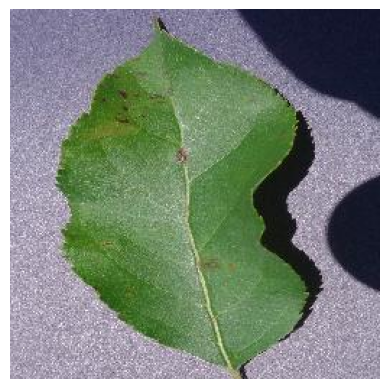

In [12]:
image_path='/content/plantvillage dataset/color/Apple___Apple_scab/fdc58f83-8a94-4f0c-aefe-c6f2b5028682___FREC_Scab 3014.JPG'

#read the image
img=mpimg.imread(image_path)

print(img.shape)
#display the image
plt.imshow(img)
plt.axis('off')  #turn off axis numbers
plt.show()

In [13]:
#image parameters
img_size=224
batch_size=32

In [14]:
#image data generators
data_gen=ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2 #use 20% of data for validation
)

In [15]:
#train generator
train_generator=data_gen.flow_from_directory(
    base_dir,
    target_size=(img_size, img_size),
    batch_size=batch_size,
    subset='training',
    class_mode='categorical'
)

Found 43456 images belonging to 38 classes.


In [16]:
#validation generator
validation_generator=data_gen.flow_from_directory(
    base_dir,
    target_size=(img_size, img_size),
    batch_size= batch_size,
    subset='validation',
    class_mode='categorical'
)

Found 10849 images belonging to 38 classes.


In [17]:
train_generator.num_classes

38

convolutional neural networks

In [18]:
#model definition
model=models.Sequential()

model.add(layers.Conv2D(32,(3,3),activation='relu',input_shape=(img_size,img_size,3)))
model.add(layers.MaxPooling2D(2,2))

model.add(layers.Conv2D(64,(3,3),activation='relu'))
model.add(layers.MaxPooling2D(2,2))

model.add(layers.Flatten())
model.add(layers.Dense(256,activation='relu'))
model.add(layers.Dense(train_generator.num_classes,activation='softmax'))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [19]:
#model summary
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 186624)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │    47,776,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 38)             │         9,766 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 47,805,158 (182.36 MB)

 Trainable params: 47,805,158 (182.36 MB)

 Non-trainable params: 0 (0.00 B)

In [20]:
#compile the model
model.compile(optimizer='adam',
              loss='categorical_crossentropy',
              metrics=['accuracy'])

In [21]:
##training the model
history=model.fit(
    train_generator,
    steps_per_epoch=train_generator.samples // batch_size,
    epochs=5,
    validation_data=validation_generator,
    validation_steps=validation_generator.samples // batch_size
)

Epoch 1/5
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 105s 72ms/step - accuracy: 0.7459 - loss: 0.9056 - val_accuracy: 0.8567 - val_loss: 0.4593
Epoch 2/5
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 92s 68ms/step - accuracy: 0.9214 - loss: 0.2459 - val_accuracy: 0.8742 - val_loss: 0.4167
Epoch 3/5
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 140s 66ms/step - accuracy: 0.9639 - loss: 0.1150 - val_accuracy: 0.8746 - val_loss: 0.4703
Epoch 4/5
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 99s 73ms/step - accuracy: 0.9754 - loss: 0.0763 - val_accuracy: 0.8843 - val_loss: 0.4775
Epoch 5/5
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 88s 65ms/step - accuracy: 0.9786 - loss: 0.0660 - val_accuracy: 0.8749 - val_loss: 0.6232


In [22]:
#model evaluation
print("Evaluaying model....")
val_loss,val_accuracy=model.evaluate(validation_generator,steps=validation_generator.samples // batch_size)
print(f'validation accuracy:{val_accuracy * 100:.2f}%')

Evaluaying model....
339/339 ━━━━━━━━━━━━━━━━━━━━ 17s 50ms/step - accuracy: 0.8749 - loss: 0.6226
validation accuracy:87.49%


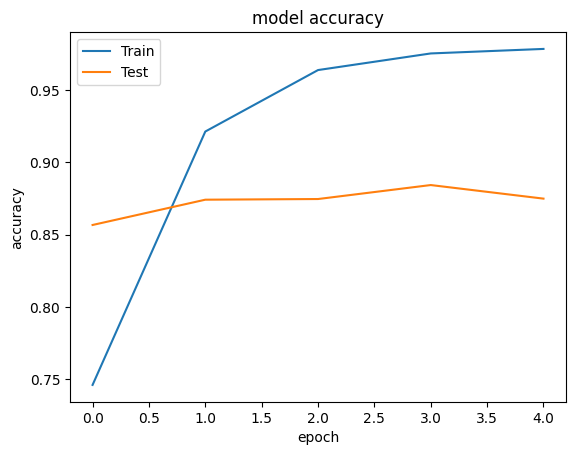

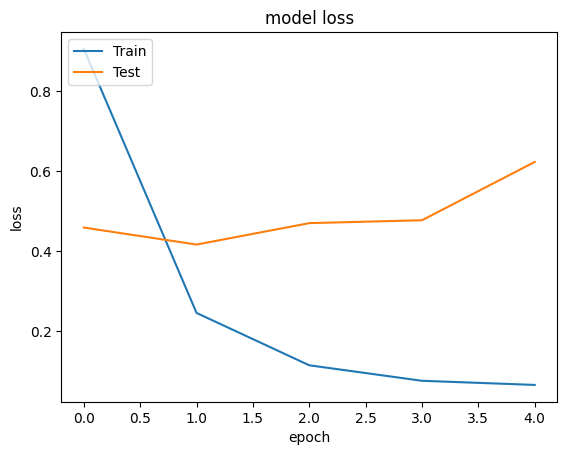

In [23]:
#plot training &validation accuracy values
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('model accuracy')
plt.ylabel('accuracy')
plt.xlabel('epoch')
plt.legend(['Train','Test'],loc='upper left')
plt.show()

#plot training &validation loss values
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('model loss')
plt.ylabel('loss')
plt.xlabel('epoch')
plt.legend(['Train','Test'],loc='upper left')
plt.show()

Building a predictive system

In [24]:
#function to load and preprocess the image using pillow
def load_and_preprocess_image(image_path,target_size=(224,224)):
  #load the image
  img=Image.open(image_path)
  #resize the image
  img=img.resize(target_size)
  #convert the image to a numpy array
  img_array=np.array(img)
  #add batch dimension
  img_array=np.expand_dims(img_array,axis=0)
  #scale the imagecvalues to [0,1]
  img_array=img_array.astype('float32')/255.
  return img_array

  #function to predict the class of an image
def predict_image_class(model,image_path,class_indices):
  preprocessed_img=load_and_preprocess_image(image_path)
  predictions=model.predict(preprocessed_img)
  predicted_class_index=np.argmax(predictions,axis=1)[0]
  predicted_class_name=class_indices[predicted_class_index]
  return predicted_class_name


In [25]:
#create a mapping from class indices to class names
class_indices={v: k for k, v in train_generator.class_indices.items()}

In [26]:
class_indices

{0: 'Apple___Apple_scab',
 1: 'Apple___Black_rot',
 2: 'Apple___Cedar_apple_rust',
 3: 'Apple___healthy',
 4: 'Blueberry___healthy',
 5: 'Cherry_(including_sour)___Powdery_mildew',
 6: 'Cherry_(including_sour)___healthy',
 7: 'Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot',
 8: 'Corn_(maize)___Common_rust_',
 9: 'Corn_(maize)___Northern_Leaf_Blight',
 10: 'Corn_(maize)___healthy',
 11: 'Grape___Black_rot',
 12: 'Grape___Esca_(Black_Measles)',
 13: 'Grape___Leaf_blight_(Isariopsis_Leaf_Spot)',
 14: 'Grape___healthy',
 15: 'Orange___Haunglongbing_(Citrus_greening)',
 16: 'Peach___Bacterial_spot',
 17: 'Peach___healthy',
 18: 'Pepper,_bell___Bacterial_spot',
 19: 'Pepper,_bell___healthy',
 20: 'Potato___Early_blight',
 21: 'Potato___Late_blight',
 22: 'Potato___healthy',
 23: 'Raspberry___healthy',
 24: 'Soybean___healthy',
 25: 'Squash___Powdery_mildew',
 26: 'Strawberry___Leaf_scorch',
 27: 'Strawberry___healthy',
 28: 'Tomato___Bacterial_spot',
 29: 'Tomato___Early_blight',
 30: '

In [27]:
#saving the class names as json file
json.dump(class_indices,open('class_indices.json','w'))

In [29]:
#example usage
#image_path='/content/028d1f49-303d-46b6-ae2b-50862fab78ca___JR_FrgE.S 2748.JPG'
image_path='/content/11594f0c-5802-43f4-9281-610a908387d4___RS_HL 2002.JPG'
#image_path='/content/0137389a-9b78-4a94-afdb-c2b50861f89c___RS_HL 2347.JPG'
predicted_class_name=predict_image_class(model,image_path,class_indices)

#output the result
print('predicted class name:',predicted_class_name)

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
predicted class name: Strawberry___healthy


save the model to google drive

In [ ]:
model.save('drive/MyDrive/DL/trained_models/plant_disease_prediction_model.h5')